# Machine Learning — Homework 1: Regression and Generalization

**Course:** Machine Learning — National University of Kyiv-Mohyla Academy (NaUKMA)
**Instructor:** Dmytro Kuzmenko (kuzmenko@ukma.edu.ua)
**Module:** Week 2 — *"Learning a Function (Regression)"*

## Meta

- **Points:** 5 (Homework 1 of 6; homeworks total 30% of the final grade)
- **Estimated time:** 2.5–3.5 hours
- **Prerequisites:** Weeks 1–2. Python, `numpy`, `matplotlib`, `scikit-learn` (`Pipeline`, `PolynomialFeatures`, `LinearRegression`, `Ridge`, `train_test_split`).
- **Deadline:** [to be announced by the instructor]
- **Submission:** one executed `.ipynb` file with the AI Use Disclosure completed.
- **Late policy:** 5 free late days across all homeworks; 1 late day = up to 24 h; after that, −25% of the maximum per additional 24 h.

## AI Use Disclosure

Policy: AI tools are allowed for homeworks, but you must disclose their use and remain responsible for every claim in your submission. On the midterm and final, AI and external help are forbidden.

- **AI tools used:** ... Юзав тільки джеміні, або шукав просто в інтернеті на сайтах.
- **Nature of assistance:** ... для пояснення незрозумілих термінів, формул, а іноді в цілому по завданню що від мене потребується пояснити і що саме відбувається, трошки для оформлення відповіді.
- **Representative prompts or relevant interaction:** ... наприклад "що таке ridge" і щось у такому плані, також деякі питання щоб впевнитися що я все правильно перевів з англійської
- **What I independently verified or changed:** ...  аналіз графіків, перевірив та звірив розраховані значення помилок, проаналізував графіки залишків та порівняв їх зі зміною рівня шуму і розміру вибірки, сформулював відповіді та висновки спираючись на отримані графічні та числові результати.

## Learning Objectives

- Fit polynomial regression models of increasing complexity and read a train/validation error curve.
- Select a model on a validation set and explain the role of train/validation/test splits.
- Use ridge regularization to control variance and diagnose fit quality from residual plots.
- Reason counterfactually about data size, noise level, and the choice of loss.

# Warm-up

We model a smooth 1-D function with noise. The data are generated in this notebook, so every run is reproducible without downloads: 250 points, $y = \sin(x) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.25)$, $x$ uniform in $[-3, 3]$. The data are split once, up front, into train / validation / test.

Run the cell below: it imports the libraries, fixes all random seeds, generates the data, and plots the training and validation points together with the true curve.

Shapes -> train: (122, 1) validation: (53, 1) test: (75, 1)


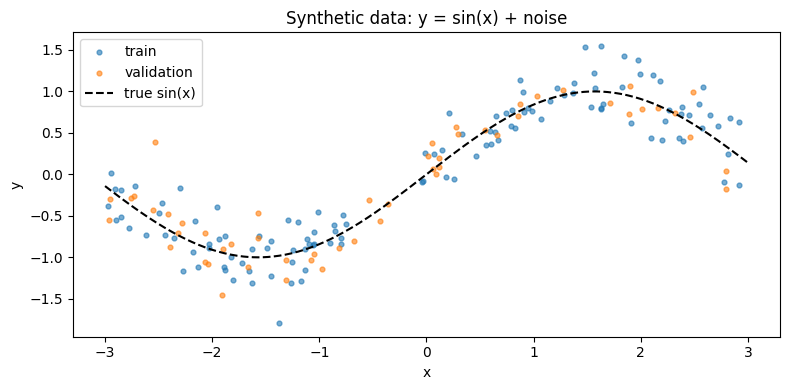

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

np.random.seed(42)

n = 250
X = np.sort(np.random.uniform(-3, 3, size=n)).reshape(-1, 1)
y = np.sin(X[:, 0]) + np.random.normal(0, 0.25, size=n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

print("Shapes -> train:", X_train.shape, "validation:", X_val.shape, "test:", X_test.shape)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X_train, y_train, s=12, alpha=0.6, label="train")
ax.scatter(X_val, y_val, s=12, alpha=0.6, label="validation")
xs = np.linspace(-3, 3, 400)
ax.plot(xs, np.sin(xs), "k--", lw=1.5, label="true sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Synthetic data: y = sin(x) + noise")
ax.legend()
plt.tight_layout()
plt.show()

A *constant-mean baseline* predicts the same value (the training mean) for every input. It ignores $x$ entirely, so it tells us the error level below which a model is actually using the signal. Compute it on all three splits:

In [2]:
base_train = np.full_like(y_train, y_train.mean())
base_val = np.full_like(y_val, y_train.mean())
base_test = np.full_like(y_test, y_train.mean())

print(f"Constant-mean baseline MSE — train: {np.mean((y_train - base_train)**2):.4f}")
print(f"Constant-mean baseline MSE — validation: {np.mean((y_val - base_val)**2):.4f}")
print(f"Constant-mean baseline MSE — test: {np.mean((y_test - base_test)**2):.4f}")

Constant-mean baseline MSE — train: 0.6751
Constant-mean baseline MSE — validation: 0.5470
Constant-mean baseline MSE — test: 0.5545


# Guided Exercise

## Task 1: Baseline and the complexity curve

Fit polynomial regression of degrees 1, 2, 3, 5, 9, and 15 via `Pipeline(PolynomialFeatures + LinearRegression)`, and record the train and validation MSE for each degree.

**Experiment (A).** Fit the six models and store the errors:

In [3]:
degrees = [1, 2, 3, 5, 9, 15]

rows = []
for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lin", LinearRegression())
    ])
    model.fit(X_train, y_train)
    train_mse = np.mean((y_train - model.predict(X_train))**2)
    val_mse = np.mean((y_val - model.predict(X_val))**2)
    rows.append({"degree": d, "train_mse": train_mse, "val_mse": val_mse})

df_curve = pd.DataFrame(rows)
df_curve

,degree,train_mse,val_mse
0,1,0.241060,0.248668
1,2,0.240867,0.246846
2,3,0.067224,0.073370
3,5,0.063910,0.063373
4,9,0.061516,0.068901
5,15,0.060666,0.066977


**Evidence (C).** Plot train vs validation MSE against the degree:

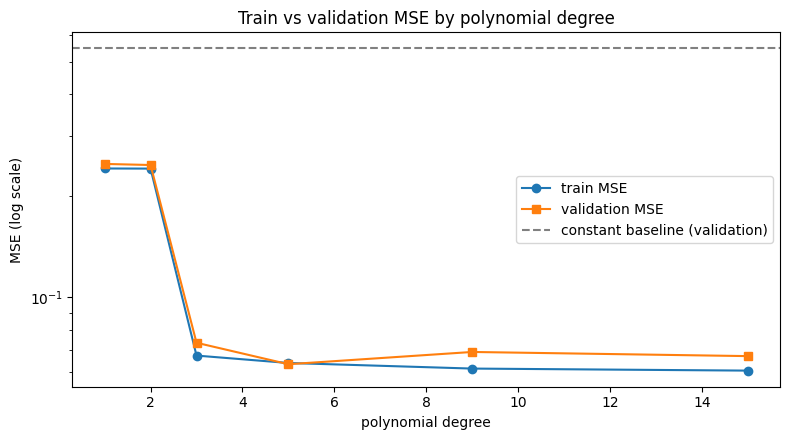

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_curve["degree"], df_curve["train_mse"], "o-", label="train MSE")
ax.plot(df_curve["degree"], df_curve["val_mse"], "s-", label="validation MSE")
ax.axhline(np.mean((y_val - y_train.mean())**2), ls="--", color="gray",
           label="constant baseline (validation)")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Train vs validation MSE by polynomial degree")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (D).** Which degrees underfit and which overfit? Where is the validation minimum, and how does the train–validation gap behave as the degree grows? Use the numbers from the table.

**Your answer:**  underfit ми спостерігаємо при степенях 1 (0.248668) та 2 (0.246846).  validation minimum маємо при степені 5 (0.063373). При степені 9 train_mse продовжує падати (до 0.061516), а val_mse зростає до 0.068901, і саме тут бачимо найбільший розрив. На степені 15 val_mse трохи знижується (до 0.066977), але train_mse падає ще сильніше (до 0.060666).

**Decision (B).** Which degree would you tentatively pick from this curve, and why? Compare degree 1 with the constant baseline from the Warm-up: what does that comparison tell you about the value of even a simple model?

**Your answer:** Я б обрав степінь 5. У нього найнижча val_mse (0.063373) і майже немає розриву з train_mse, тому модель буде так само якісно працювати на будь-яких нових точках.
При 1 степені вже помилка падає до 0.2487 з 0.5 як на baseline тому точки будуть прогнозуватися набагато краще.

**Counterfactual (E).** If you extended the sweep to degree 30, what would you expect for the train and validation MSE? What about degree 0 (a constant model)? Justify briefly.

**Your answer:** При степені 30 train_mse думаю сильно впаде, бо з такою кількістю параметрів лінія пройде майже через кожну точку. А val_mse навпаки зросте через overfitting.
При степіні 0 маємо просто горизонтальну пряму у. Для такої моделі найвигіднішим числом є звичайне середнє значення всіх наших точок у. Тому для степіня 0 ми отримаємо точно таку ж помилку, як і у нашого константного baseline.

## Task 2: Model selection via validation

Select the degree using only the validation set, then measure the final model on the test set exactly once. Keep the test set out of every choice you make.

**Experiment (A).** Refit all degrees, record validation MSE, pick the best degree, and evaluate it on the test set:

In [6]:
rows = []
for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lin", LinearRegression())
    ])
    model.fit(X_train, y_train)
    val_mse = np.mean((y_val - model.predict(X_val))**2)
    test_mse = np.mean((y_test - model.predict(X_test))**2)
    rows.append({"degree": d, "val_mse": val_mse, "test_mse": test_mse})

df_select = pd.DataFrame(rows)
best_degree = int(df_select.loc[df_select["val_mse"].idxmin(), "degree"])
print(f"Degree with the lowest validation MSE: {best_degree}")
df_select

Degree with the lowest validation MSE: 5


,degree,val_mse,test_mse
0,1,0.248668,0.203268
1,2,0.246846,0.204028
2,3,0.073370,0.057631
3,5,0.063373,0.056695
4,9,0.068901,0.057162
5,15,0.066977,0.059490


**Evidence (C).** Compare the validation and test error side by side:

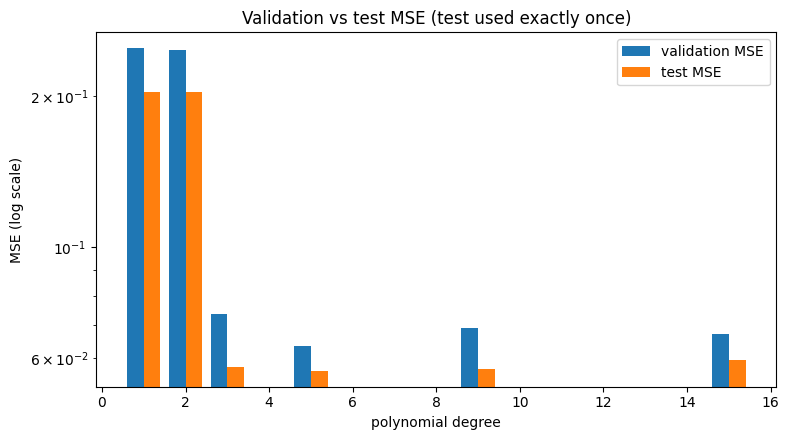

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.4
ax.bar(df_select["degree"] - width/2, df_select["val_mse"], width, label="validation MSE")
ax.bar(df_select["degree"] + width/2, df_select["test_mse"], width, label="test MSE")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Validation vs test MSE (test used exactly once)")
ax.legend()
plt.tight_layout()
plt.show()

**Decision (B).** State the chosen degree and the rule you used. Explain the role of each of the three splits: what is the training set for, what is the validation set for, and why must the test set stay untouched until the very end?

**Your answer:** Обрано степінь 5. Правило вибору полягає в пошуку степеня з мінімальною помилкою на валідаційній вибірці (val_mse = 0.063373). Тестова вибірка взагалі не бере участі в процесі прийняття рішення.
Роль трьох розділень: Training set: використовується для навчання ваг кожної окремої моделі. Validation set: використовується для порівняння різних моделей, вибору гіперпараметрів (наприклад степінь полінома як тут у нас).Test set: використовується лише один раз наприкінці для фінальної оцінки якості вже обраної моделі.

**Interpretation (D).** Compare the validation MSE of the chosen degree with its test MSE: are they close? What would happen if you picked the degree with the lowest train MSE instead?

**Your answer:** Для степеня 5 валідаційна помилка (0.063373) та тестова помилка (0.056695) є дуже близькими. Тестова помилка виявилася навіть трохи нижчою за валідаційну, що підтверджує: обрана модель добре узагальнює закономірність і не перенавчилася під валідаційні точки.
Якщо обирати за найнижчим train_mse: найнижчу помилку на навчанні має степінь 15 (train_mse = 0.060666 з Task 1). Якби ми орієнтувалися на train_mse, ми б обрали перенавчену модель. На відміну від степеня 5, де test_mse досягає свого мінімуму (0.056695), у степеня 15 тестова помилка вже зростає до 0.059490 через заучування випадкового шуму.

**Counterfactual (E).** Refit the complexity curve on a training set of 30 points and on one of 100 points, and compare the two curves (the code below does the refitting):

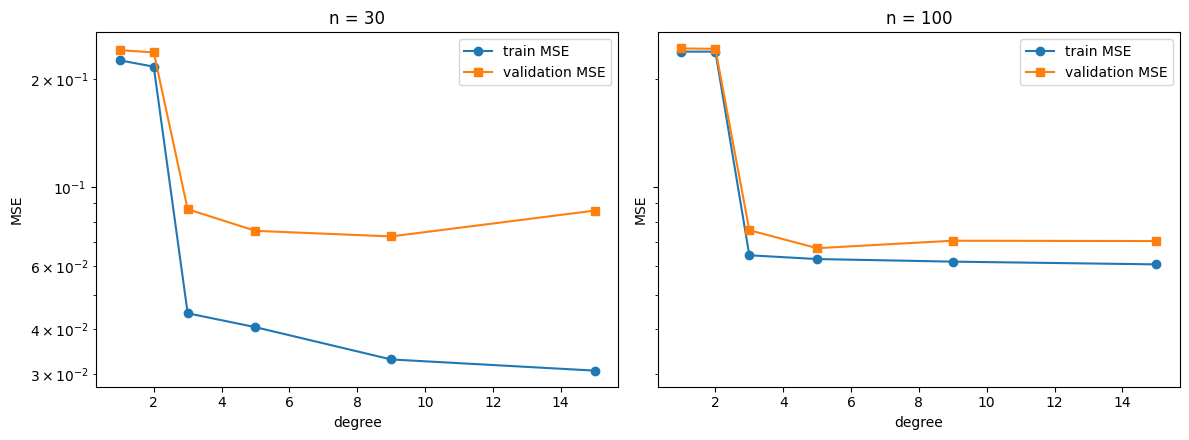

In [8]:
def complexity_curve(n_train, seed=123):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X_train), size=n_train, replace=False)
    Xs, ys = X_train[idx], y_train[idx]
    rows = []
    for d in degrees:
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("lin", LinearRegression())
        ]).fit(Xs, ys)
        rows.append({"degree": d,
                     "train_mse": np.mean((ys - model.predict(Xs))**2),
                     "val_mse": np.mean((y_val - model.predict(X_val))**2)})
    return pd.DataFrame(rows)

df_small = complexity_curve(30)
df_large = complexity_curve(100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, df, label in [(axes[0], df_small, "n = 30"), (axes[1], df_large, "n = 100")]:
    ax.plot(df["degree"], df["train_mse"], "o-", label="train MSE")
    ax.plot(df["degree"], df["val_mse"], "s-", label="validation MSE")
    ax.set_yscale("log")
    ax.set_xlabel("degree")
    ax.set_ylabel("MSE")
    ax.set_title(label)
    ax.legend()
plt.tight_layout()
plt.show()

Before reading the plots, predict: how should the curve and the selected degree change when the training set shrinks from 100 to 30 points? Then interpret the plots: which regime shows a noisier curve, a larger overfitting gap, and a less stable selected degree, and why?

**Your answer:** При зменшенні навчальної вибірки з 100 до 30 точок модель має менше даних для стримування складних поліномів. Тому очікується, що при n = 30 overfitting настане раніше, розрив між train_mse та val_mse стане більшим, а обраний оптимальний степінь зміститься в бік простіших моделей.
Більший розрив: на графіку n = 30 спостерігається значно ширший зазор між синьою та помаранчевою лініями для вищих степеней. Навчальна помилка швидко падає до дуже низьких значень, оскільки складному поліному легко пройти лише 30 точок.
Шумність та нестабільність: крива для n = 30 є більш чутливою до випадкового шуму та конкретного вибору 30 точок. Натомість при n = 100 крива є набагато плавнішою, а розрив між навчальною та валідаційною помилками — значно меншим.
Чому так відбувається: великий обсяг даних n = 100 діє як природна регуляризація. Він не дозволяє високим степеням полінома сильно коливатися між точками, змушуючи модель вивчати справжній сигнал, а не викривлятися під випадковий шум невеликої вибірки.

# Discussion Questions

Answer both questions briefly (2–4 sentences each).

**Question 1.** If train MSE ≈ validation MSE ≈ σ² (the irreducible noise variance), what does that tell you about the model's bias and variance?

**Your answer:** Якщо train MSE ≈ validation MSE ≈ σ², це означає, що модель досягла теоретично можливої межі точності для цих даних. Це свідчить про те, що і зсув, і розсіювання є низькими: модель є достатньо гнучкою, щоб повністю описати справжній сигнал, і водночас стабільною, щоб не підлаштовуватися під випадковий шум. Модель вивчила фізичну закономірність, не намагаючись зазубрити незводний шум σ².

**Question 2.** The validation set has only 53 points. What risk does choosing the degree with the minimum validation MSE carry, and what technique would reduce that risk without touching the test set?

**Your answer:** Вибір степеня полінома на малій валідаційній вибірці (N = 53) несе ризик перенавчання під валідацію через високу дисперсію самої вибірки. Випадковий розподіл лише 53 точок може випадково зробити невдалий степінь найкращим просто за везінням. Щоб суттєво зменшити цей ризик і не чіпати test set, слід використати K-fold крос-валідацію на об'єднаних навчальних і валідаційних даних, що дозволить усереднити помилку за кількома фолдами.

# Challenge

## Task 3: Regularization and residual diagnostics

Keep the flexible degree-15 features, but replace plain least squares with ridge regression. Sweep the regularization strength α over a wide log range; the features are standardized inside the pipeline so that the penalty is meaningful.

**Experiment (A).** Sweep α and find the best value on validation:

In [9]:
alphas = np.logspace(-4, 3, 30)

def ridge_pipeline(alpha):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scale", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

rows = []
for a in alphas:
    model = ridge_pipeline(a).fit(X_train, y_train)
    rows.append({"alpha": a,
                 "train_mse": np.mean((y_train - model.predict(X_train))**2),
                 "val_mse": np.mean((y_val - model.predict(X_val))**2),
                 "test_mse": np.mean((y_test - model.predict(X_test))**2)})
df_ridge = pd.DataFrame(rows)

best_alpha = float(df_ridge.loc[df_ridge["val_mse"].idxmin(), "alpha"])
print(f"Best alpha on validation: {best_alpha:.4f} "
      f"(validation MSE {df_ridge['val_mse'].min():.4f})")
print("For reference, unregularized degree 15: "
      "validation MSE {:.4f}".format(df_select.loc[df_select["degree"] == 15, "val_mse"].iloc[0]))

Best alpha on validation: 0.1374 (validation MSE 0.0628)
For reference, unregularized degree 15: validation MSE 0.0670


**Evidence (C).** Two plots: the ridge path (validation MSE vs α), and residuals vs x for three models — underfit (degree 1), overfit (degree 15 without regularization), and the regularized model at the best α:

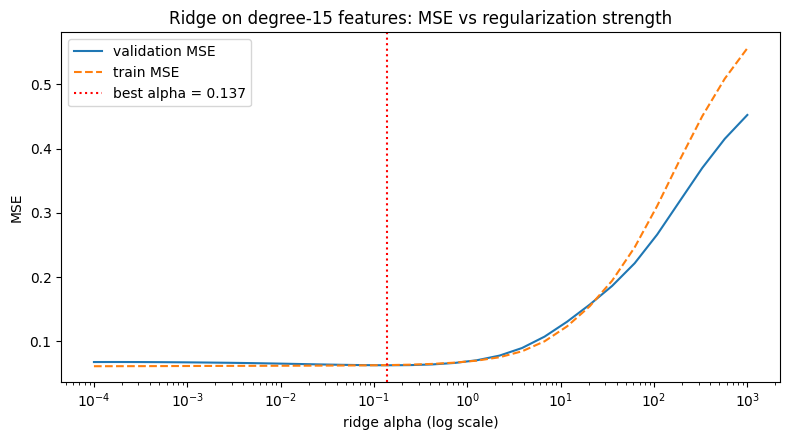

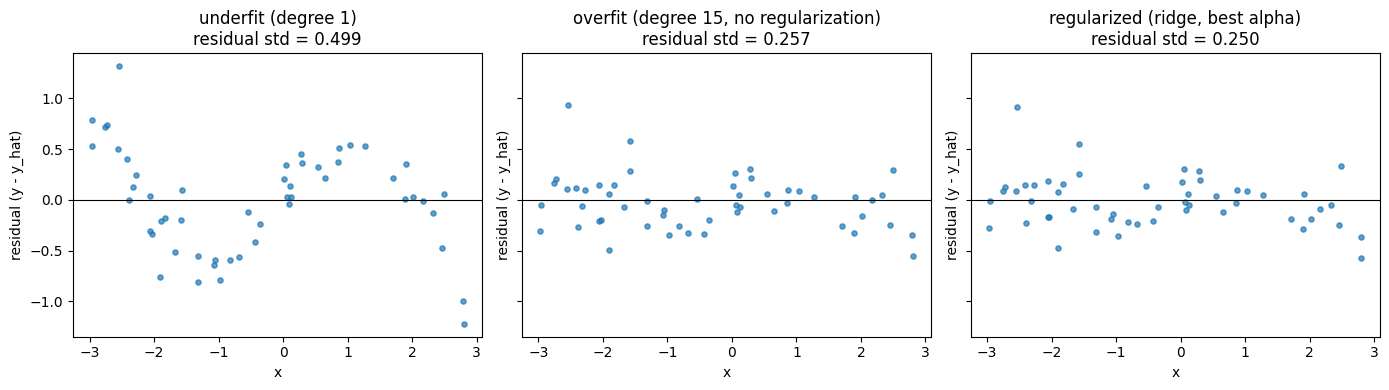

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(df_ridge["alpha"], df_ridge["val_mse"], "-", label="validation MSE")
ax.semilogx(df_ridge["alpha"], df_ridge["train_mse"], "--", label="train MSE")
ax.axvline(best_alpha, color="red", ls=":", label=f"best alpha = {best_alpha:.3f}")
ax.set_xlabel("ridge alpha (log scale)")
ax.set_ylabel("MSE")
ax.set_title("Ridge on degree-15 features: MSE vs regularization strength")
ax.legend()
plt.tight_layout()
plt.show()

models = {
    "underfit (degree 1)": Pipeline([
        ("poly", PolynomialFeatures(1, include_bias=False)),
        ("lin", LinearRegression())
    ]).fit(X_train, y_train),
    "overfit (degree 15, no regularization)": Pipeline([
        ("poly", PolynomialFeatures(15, include_bias=False)),
        ("scale", StandardScaler()),
        ("lin", LinearRegression())
    ]).fit(X_train, y_train),
    "regularized (ridge, best alpha)": ridge_pipeline(best_alpha).fit(X_train, y_train),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    resid = y_val - model.predict(X_val)
    ax.scatter(X_val, resid, s=14, alpha=0.7)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("x")
    ax.set_ylabel("residual (y - y_hat)")
    ax.set_title(f"{name}\nresidual std = {resid.std():.3f}")
plt.tight_layout()
plt.show()

**Decision (B).** Which α do you choose, and why? At what α does ridge effectively behave like the unregularized degree-15 fit, and what happens when α becomes very large (e.g., 1000)?

**Your answer:** Я обираю α = 0.1374, оскільки саме при цьому значенні досягається мінімальна помилка на валідації (val_mse = 0.0628). Це покращує якість порівняно з нерегуляризованим поліномом 15-го степеня (val_mse = 0.0670).
При дуже малих α Ridge поводиться майже ідентично до звичайної регресії без регуляризації, оскільки штраф за ваги є малим.
Коли α стає надто великим, штраф настільки сильно затискає коефіцієнти, що всі ваги прямують до нуля. Модель перетворюється на константу, через що й train_mse, і val_mse стрімко зростають до рівень під під приблизно 0.5.

**Interpretation (D).** Compare the three residual plots. What structure do you see in the underfit residuals and what does it mean? What about the overfit and regularized ones? Why is "structure in residuals = missed signal" a useful diagnostic?

**Your answer:** Underfit (степінь 1): на графіку залишків чітко видно систематичну S-подібну хвилю (синусоїду), а стандартне відхилення залишків є найвищим (std = 0.499). Це свідчить про те, що пряма лінія не змогла вловити вигини даних, і нез'ясована закономірність «витекла» в залишки.
Overfit (степінь 15, без регуляризації): залишки вже більш хаотичні, але мають невеликі викривлення та сплески на краях через коливання полінома (std = 0.257).
Regularized: Залишки розподілені рівномірно та випадково навколо нульової лінії без жодного помітного паттерна чи форми (std = 0.250).
Why is "structure in residuals = missed signal" a useful diagnostic?
Ідеальні залишки мають бути чистим випадковим шумом. Якщо в залишках простежується якась форма, графік або тренд, це прямий доказ того, що модель занадто проста і пропустила корисну закономірність у даних, виштовхнувши її в помилки.

**Counterfactual (E).** If α were pushed to 0 (no penalty) or to 10⁶, what would happen to train and validation MSE? We standardized the features before penalizing — does the meaning of α change compared with fitting on raw features? Justify briefly.

**Your answer:** При α до 0 штраф зникає, і модель повертається до звичайної Linear Regression 15-го степеня: train_mse впаде до мінімуму, а val_mse зросте через перенавчання.
При α до 10⁶ модель буде повністю затиснута (всі ваги дорівнюють 0), перетворившись на константний baseline. І train_mse, і val_mse зростуть до близько 0.5.
Вплив стандартизації ознак:
Значення та сенс α суттєво змінюються. Поліноміальні степені мають абсолютно різні масштаби значень (наприклад, 3^15 — це мільйони, тоді як 3^1 = 3). Без стандартизації Ridge-штраф регуляризації нерівномірно давив би на високі степені. Зі StandardScaler усі ознаки мають однакове дисперсійне масштабування, тому α штрафує вплив усіх степеней однакове й збалансовано.

## Task 4: Counterfactuals and synthesis

Two final probes: (a) how does the noise level σ reshape the complexity curve, and (b) would switching the loss from MSE to MAE change the chosen degree? Finish with a short written conclusion.

**Counterfactual (E), part 1 — predict first.** Before running the code, predict: if σ increases from 0.1 to 1.0, what happens to (i) all MSE values, (ii) the train–validation gap at high degrees, (iii) the degree selected by validation?

**Your answer:**  Перед запуском коду робимо наступний прогноз:(i) усі значення MSE: загальний рівень помилок (train_mse та val_mse) суттєво зросте для всіх степеней, оскільки незводний шум σ² є нижньою теоретичною межею помилки.(ii) розрив train–validation при високих степенях: розрив між train_mse та val_mse для складних поліномів (d = 15) катастрофічно збільшиться. Високий рівень шуму провокує сильну осциляцію кривої, адже модель намагається зазубрити цей шум.(iii) Степінь, обраний валідацією: оптимальний степінь зменшиться (зміститься в бік простіших моделей, наприклад d = 3 або d = 1), оскільки на високому шумі складні моделі миттєво перенавчаються.

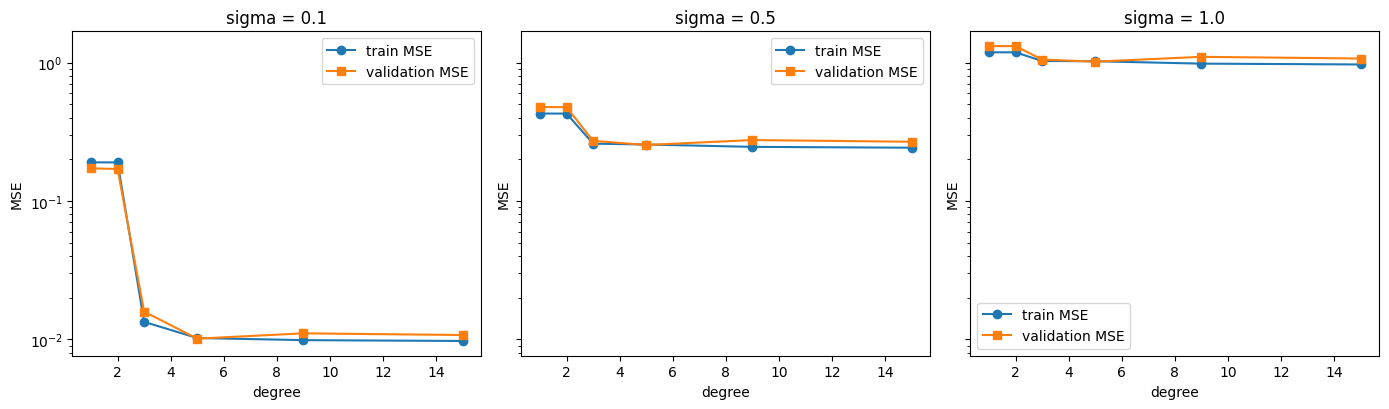

In [11]:
def noise_curve(sigma, seed=42):
    rng = np.random.RandomState(seed)
    Xs = np.sort(rng.uniform(-3, 3, size=n)).reshape(-1, 1)
    ys = np.sin(Xs[:, 0]) + rng.normal(0, sigma, size=n)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.3, random_state=42)
    Xtr, Xva, ytr, yva = train_test_split(Xtr, ytr, test_size=0.3, random_state=42)
    rows = []
    for d in degrees:
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("lin", LinearRegression())
        ]).fit(Xtr, ytr)
        rows.append({"degree": d,
                     "train_mse": np.mean((ytr - model.predict(Xtr))**2),
                     "val_mse": np.mean((yva - model.predict(Xva))**2)})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, sigma in zip(axes, [0.1, 0.5, 1.0]):
    df_noise = noise_curve(sigma)
    ax.plot(df_noise["degree"], df_noise["train_mse"], "o-", label="train MSE")
    ax.plot(df_noise["degree"], df_noise["val_mse"], "s-", label="validation MSE")
    ax.set_yscale("log")
    ax.set_xlabel("degree")
    ax.set_ylabel("MSE")
    ax.set_title(f"sigma = {sigma}")
    ax.legend()
plt.tight_layout()
plt.show()

**Counterfactual (E), part 2 — verify and interpret.** Did the results match your prediction? Quantify at least one effect (e.g., the overfitting gap at degree 15 for σ = 0.1 vs σ = 1.0) and explain why the selected degree is or is not stable across noise levels.

**Your answer:**  Результати повністю підтвердили прогноз:Точна оцінка з графіків: При ніжному шумі σ = 1.0 помилка падає дуже низько — аж до близько   0.01 (степінь 5). Коли ж шум зростає до σ = 1.0, помилка злітає в 100 разів і застрягає на рівні >1.0 для всіх моделей. Чому степінь нестабільний: при малому шумі сигнал синусоїди чіткий, тому валідація легко знаходить вигини й обирає степінь 5. При σ = 1.0 шум повністю заглушає синусоїду, через що графік помилки стає майже пласким, і складні поліноми більше не дають жодної переваги.

**Decision (B) / Interpretation (D) — changing the loss.** If the loss switched from MSE to MAE, would the chosen degree likely change? Think about sensitivity to outliers and how the error surface differs, then give a reasoned answer (no need to run code).

**Your answer:** Зміна MSE на MAE може помітно змінити вибір степеня:
MSE (квадратична помилка) дуже сильно покарання ставить за великі промахи. Якщо високий степінь починає сильно дико вигинатися десь на краях, MSE це миттєво відкидає.
MAE (абсолютна помилка) оцінює промахи лінійно й набагато спокійніше ставиться до поодиноких викидів чи сплесків. Вона може пробачити складному поліному декілька різких вигинів, тому валідація за MAE може випадково обрати більш гнучку модель.

**Conclusion.** Write a short conclusion (3–5 sentences) synthesizing how model complexity, data size, regularization, and noise interact in regression, and which two ideas from this homework you would reuse first in a real project.

**Your answer:** У регресії все вирішує баланс: складна модель працює добре тільки тоді, коли є багато даних і мало шуму, а Ridge-регуляризація допомагає приборкати складні поліноми. Найцінніші дві ідеї, які я застосую в реальних проєктах: повна ізоляція тестової вибірки до самого кінця, щоб оцінка була чесною. Ridge-регуляризація зі стандартизацією ознак, щоб будувати гнучкі моделі й не боятися перенавчання.

## Takeaways

- Model complexity is a dial: low complexity underfits (high bias), excessive complexity overfits (high variance); the validation set is the honest referee.
- The test set is measured exactly once; selection happens on validation only.
- Regularization (ridge) trades a little bias for a large variance cut — it lets you keep flexible features under control.
- Residual plots reveal structure left in the data: structure means missed signal.
- Counterfactual reasoning (smaller data, more noise, a different loss) builds intuition about when a method will and will not work.